In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, FalseNegatives, FalsePositives, TrueNegatives, TruePositives, AUC
from tensorflow.math import confusion_matrix
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from tensorflow.keras.preprocessing import image_dataset_from_directory
from PIL import Image
from tqdm import tqdm
from keras.preprocessing import image
from tensorflow.keras.layers import Layer, InputSpec
import tensorflow.python.keras.engine
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.python.keras.utils import layer_utils
from keras.applications.vgg16 import VGG16
from tensorflow.keras.models import load_model
from keras.layers import Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import AUC, Accuracy, Recall, Precision
from sklearn.metrics import f1_score

In [2]:
TRAINING_DIR = r"D:\cap stone project\Data set\Train"
TEST_DIR = r"D:\cap stone project\Data set\Test"
VALIDATION_DIR = r"D:\cap stone project\Data set\Validation"

print(f'Total training images REAL: {len(os.listdir(os.path.join(TRAINING_DIR, "real")))}')
print(f'Total training images FAKE: {len(os.listdir(os.path.join(TRAINING_DIR, "fake")))}\n')

print(f'Total test images REAL: {len(os.listdir(os.path.join(TEST_DIR, "real")))}')
print(f'Total test images FAKE: {len(os.listdir(os.path.join(TEST_DIR, "fake")))}\n')

print(f'Total test images REAL: {len(os.listdir(os.path.join(VALIDATION_DIR, "real")))}')
print(f'Total test images FAKE: {len(os.listdir(os.path.join(VALIDATION_DIR, "fake")))}')

Total training images REAL: 70001
Total training images FAKE: 70001

Total test images REAL: 5413
Total test images FAKE: 5492

Total test images REAL: 19787
Total test images FAKE: 19641


In [3]:
training_datagen = ImageDataGenerator(
    rescale=1./255,
    #validation_split=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

img_size = 224
img_batch = 32

train_generator = training_datagen.flow_from_directory(
    TRAINING_DIR,
    subset='training',
    target_size=(img_size, img_size),
    shuffle=True,
    class_mode='binary',
    batch_size=img_batch
)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    #subset='validation',
    target_size=(img_size, img_size),
    shuffle=True,
    class_mode='binary',
    batch_size=img_batch
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(img_size, img_size),
    class_mode='binary',
    batch_size=img_batch,
    shuffle=False
)

Found 140002 images belonging to 2 classes.
Found 39428 images belonging to 2 classes.
Found 10905 images belonging to 2 classes.


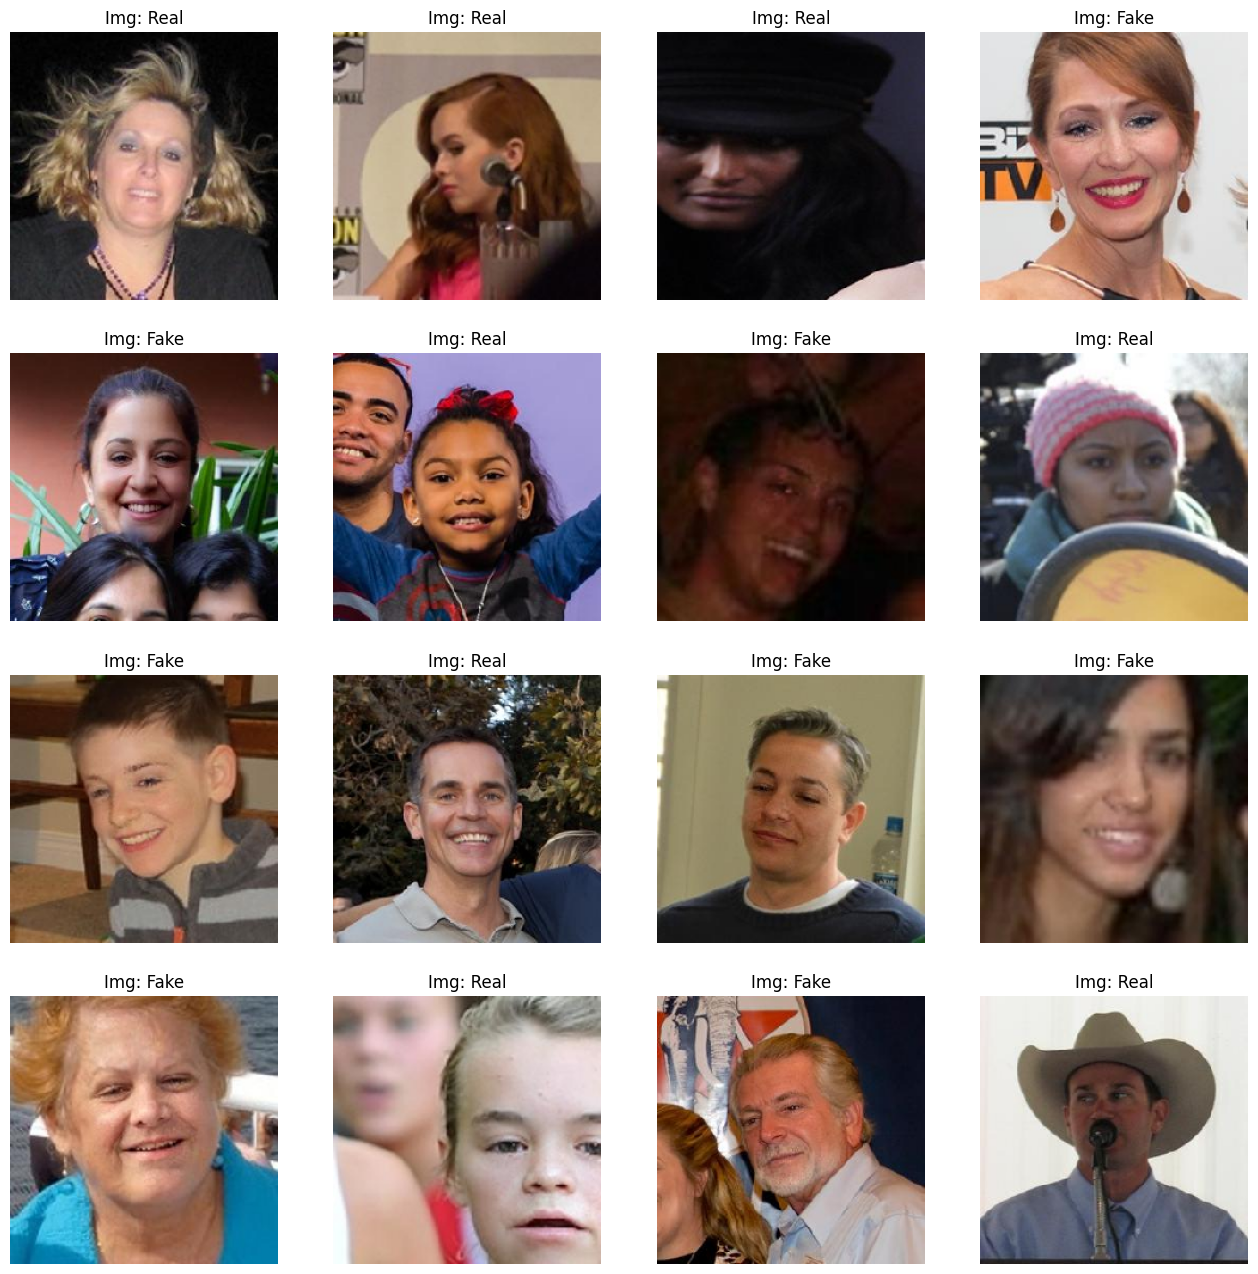

In [4]:
labels = {1.0: 'Real', 0.0: 'Fake'}

for images, images_labels in train_generator:
    plt.figure(figsize=(16, 16))
    
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.title(f'Img: {labels[images_labels[i]]}')
        plt.imshow(np.uint8(255 * images[i]))
        plt.axis('off')
    break

In [19]:
vgg_model = VGG16(include_top=False, weights='imagenet', input_shape=(img_size, img_size, 3))

for layer in vgg_model.layers:
    layer.trainable = False

last_layer = vgg_model.get_layer('block5_pool').output
x = Flatten(name='flatten')(last_layer)
x = Dense(512, activation='relu', name='fc6')(x)
x = Dropout(0.5)(x)
out = Dense(1, activation='sigmoid', name='fc8')(x)
custom_vgg_model = Model(vgg_model.input, out)
custom_vgg_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc6 (Dense)                     │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc8 (Dense)                     │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,560,769 (105.14 MB)

 Trainable params: 12,846,081 (49.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
custom_vgg_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

callback = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='model.keras',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    )
]

history = custom_vgg_model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    verbose=1,
    callbacks=callback
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7146 - loss: 1.3239
Epoch 1: val_loss improved from inf to 0.28868, saving model to model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 1991s 6s/step - accuracy: 0.7148 - loss: 1.3218 - val_accuracy: 0.8920 - val_loss: 0.2887
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8283 - loss: 0.3796
Epoch 2: val_loss did not improve from 0.28868
313/313 ━━━━━━━━━━━━━━━━━━━━ 1960s 6s/step - accuracy: 0.8283 - loss: 0.3796 - val_accuracy: 0.8380 - val_loss: 0.3432
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8511 - loss: 0.3279
Epoch 3: val_loss improved from 0.28868 to 0.26316, saving model to model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 1952s 6s/step - accuracy: 0.8511 - loss: 0.3279 - val_accuracy: 0.8890 - val_loss: 0.2632
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8582 - loss: 0.3184
Epoch 4: val_loss did not improve from 0.26316
313/313 ━━━━━━━━━━━━━━━━━━━━ 1941s 6s/step - accuracy

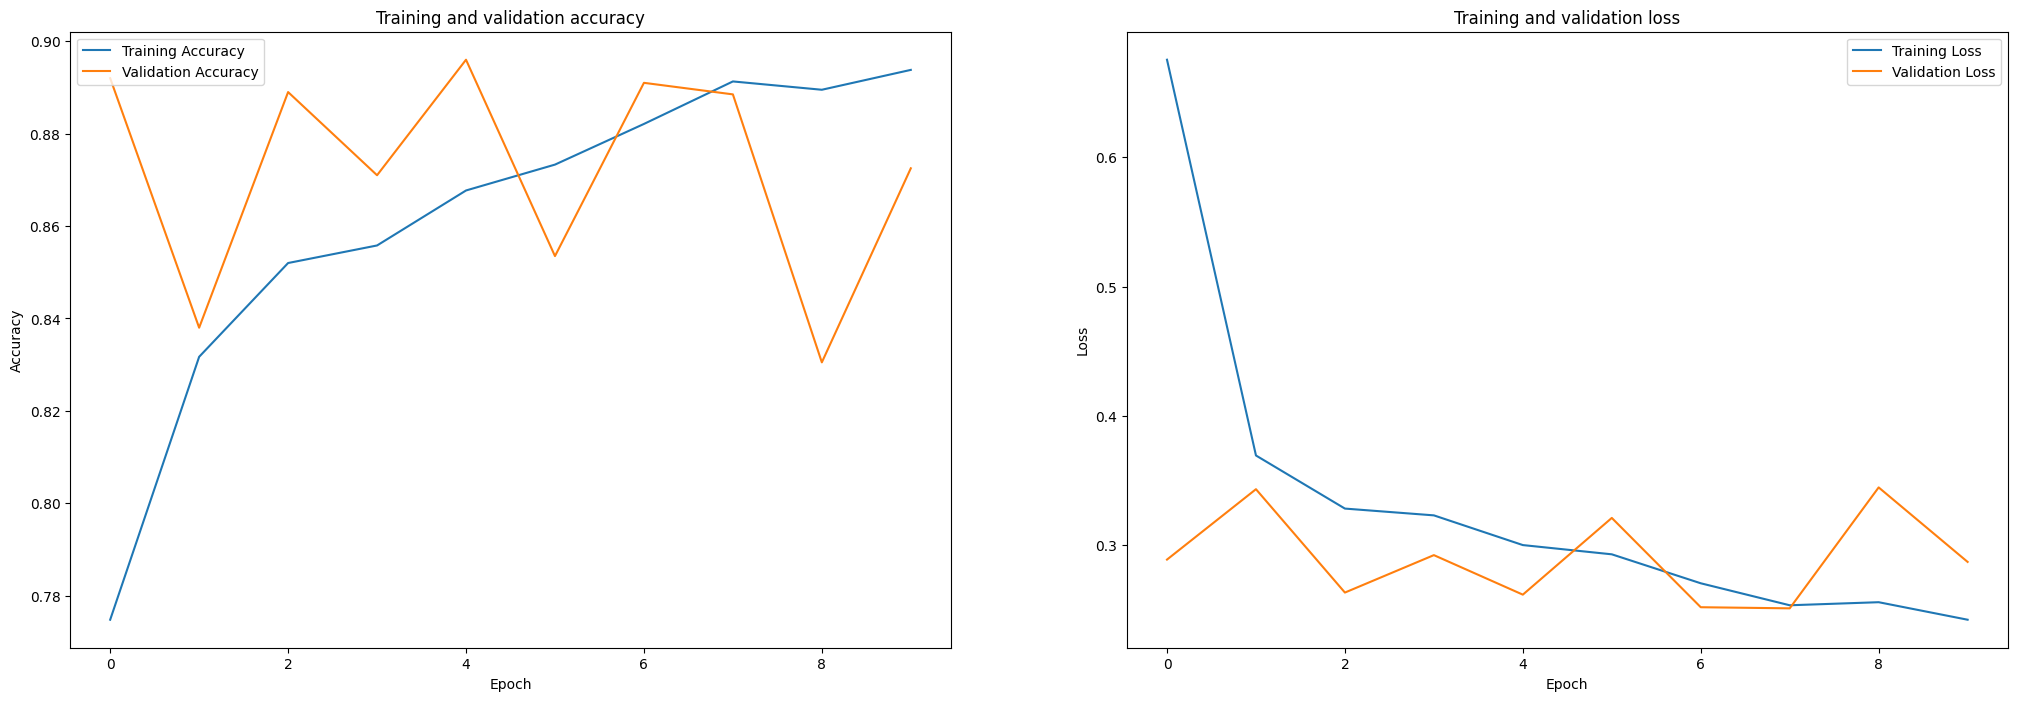

In [21]:
plt.figure(figsize=(25, 8))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

In [22]:
metrics = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
index_model_checkpoint = np.argmin(history.history['val_loss'])
[f'Best {metric}: {history.history[metric][index_model_checkpoint]:.2f}' for metric in metrics]

['Best accuracy: 0.89',
 'Best val_accuracy: 0.89',
 'Best loss: 0.25',
 'Best val_loss: 0.25']

In [5]:
def load_and_test_model(model_name, test_set, display_model_summary=False):
    try:
        loaded_model = tf.keras.models.load_model(f'model.keras')
    except OSError:
        print('The model called does not exist. Testing for the last saved model.')
        loaded_model = tf.keras.models.load_model('model.keras') # This is the name used in the ModelCheckpoint
    if display_model_summary:
        loaded_model.summary()
    test_loss, test_acc = loaded_model.evaluate(test_set)
    print(f'Test loss: {round(test_loss, 2)}, Test accuracy: {round(test_acc * 100, 2)}')

In [6]:
load_and_test_model('model', test_generator)

C:\Users\rsiva\AppData\Roaming\Python\Python312\site-packages\keras\src\saving\saving_lib.py:396: UserWarning: Skipping variable loading for optimizer 'adam', because it has 62 variables whereas the saved optimizer has 10 variables. 
  trackable.load_own_variables(weights_store.get(inner_path))
C:\Users\rsiva\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


341/341 ━━━━━━━━━━━━━━━━━━━━ 2782s 8s/step - accuracy: 0.7374 - loss: 0.5591
Test loss: 0.46, Test accuracy: 78.87


In [7]:
def calculate_model_performance_metrics(model_name, test_dataset, transfer_ml=False, model_version=0,
                                        show_plots=False):
    
    try:
        loaded_model = tf.keras.models.load_model(f'model.keras')
        print(f'Calculating performance metrics for model')
    except OSError:
        print('The model called does not exist. Testing for the last saved model.')
        loaded_model = tf.keras.models.load_model('model.keras')

    if transfer_ml and model_version != 0:
        test_images, true_labels = test_dataset.as_numpy_iterator().next()
        test_images = layer_utils.preprocess_input(test_images, version=model_version)
        predictions_sigmoid = loaded_model.predict(test_images, verbose=1)
    else:
        true_labels = test_dataset.labels
        predictions_sigmoid = loaded_model.predict(test_dataset, verbose=1)
    
    false_positives_negatives = []
    lower_bound_threshold = 0.2
    upper_bound_threshold = 0.7
    step = 0.001

    sigmoid_threshold = np.arange(lower_bound_threshold, upper_bound_threshold, step)

    for threshold in sigmoid_threshold:
        predictions_binary = tf.where(predictions_sigmoid > threshold, 1, 0)
        conf_matrix = confusion_matrix(true_labels, predictions_binary)
        false_positives_negatives.append(conf_matrix[0][1] + conf_matrix[1][0])

    min_threshold = sigmoid_threshold[np.argmin(false_positives_negatives)]
    print(f'Minimizer of false positives and false negatives: {min_threshold:.3f}')

    metrics_options = {
        'Precision': Precision,
        'Recall': Recall,
        'True Positives': TruePositives,
        'True Negatives': TrueNegatives,
        'False Positives': FalsePositives,
        'False Negatives': FalseNegatives
    }

    def disp_metrics(metric, threshold_value=min_threshold, verbose=False):
        metrics = metrics_options[metric](thresholds=threshold_value)
        metrics.update_state(true_labels, predictions_sigmoid)
        result = metrics.result().numpy()
        if verbose:
            print(f'{metric}: {result:.3f}')
        return result

    bin_acc = BinaryAccuracy(threshold=min_threshold)
    bin_acc.update_state(true_labels, predictions_sigmoid)
    print(f'Binary Accuracy: {bin_acc.result().numpy():.3f}')

    for metric in metrics_options.keys():
        disp_metrics(metric, verbose=True)

    rights = disp_metrics('True Positives') + disp_metrics('True Negatives')
    wrongs = disp_metrics('False Positives') + disp_metrics('False Negatives')
    print(f'Number of right guesses: {rights:.3f}')
    print(f'Number of wrong guesses: {wrongs:.3f}')

    auc = AUC()
    auc.update_state(true_labels, predictions_sigmoid)
    auc = auc.result().numpy()
    print(f'Area under curve ROC: {auc:.3f}')

    precision = disp_metrics('Precision')
    recall = disp_metrics('Recall')

    f1_score = 2 * (precision * recall) / (precision + recall)
    print(f'F1-Score: {f1_score:.3f}')


    if show_plots:
        
        plt.figure(figsize=(18, 14))
    
        plt.subplot(2, 2, 1)
        plt.plot(sigmoid_threshold, false_positives_negatives, linewidth=3)
        plt.title('Sum of false positives and false negatives as a function of sigmoid threshold')
        plt.xlabel('Sigmoid threshold')
        plt.ylabel('False positives + False negatives')

        plt.subplot(2, 2, 2)
        cm = confusion_matrix(true_labels, tf.where(predictions_sigmoid > min_threshold, 1, 0))
        sns.heatmap(cm, annot=True, fmt="d")
        plt.title(f'Confusion matrix @{min_threshold:.3f}')
        plt.ylabel('Actual label')
        plt.xlabel('Predicted label')

        plt.subplot(2, 2, 3)
        false_positive_rate, true_positive_rate, _ = roc_curve(true_labels, predictions_sigmoid)
        plt.plot(false_positive_rate, true_positive_rate, linewidth=4)
        plt.title(f'Receiver Operating Characteristic curve for AUC: {auc:.3f}')
        plt.xlabel('False positive rate')
        plt.ylabel('True positives rate')
        plt.grid(True)

        plt.subplot(2, 2, 4)
        prec, rec, _ = precision_recall_curve(true_labels, predictions_sigmoid)
        plt.plot(rec, prec, linewidth=4)
        avg_precision_score = average_precision_score(true_labels, predictions_sigmoid)
        plt.title(f'Precision-Recall curve | Average precision score: {avg_precision_score:.3f}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.grid(True)
    
    return min_threshold

Calculating performance metrics for model
341/341 ━━━━━━━━━━━━━━━━━━━━ 2758s 8s/step
Minimizer of false positives and false negatives: 0.572
Binary Accuracy: 0.791
Precision: 0.772
Recall: 0.821
True Positives: 4443.000
True Negatives: 4183.000
False Positives: 1309.000
False Negatives: 970.000
Number of right guesses: 8626.000
Number of wrong guesses: 2279.000
Area under curve ROC: 0.879
F1-Score: 0.796


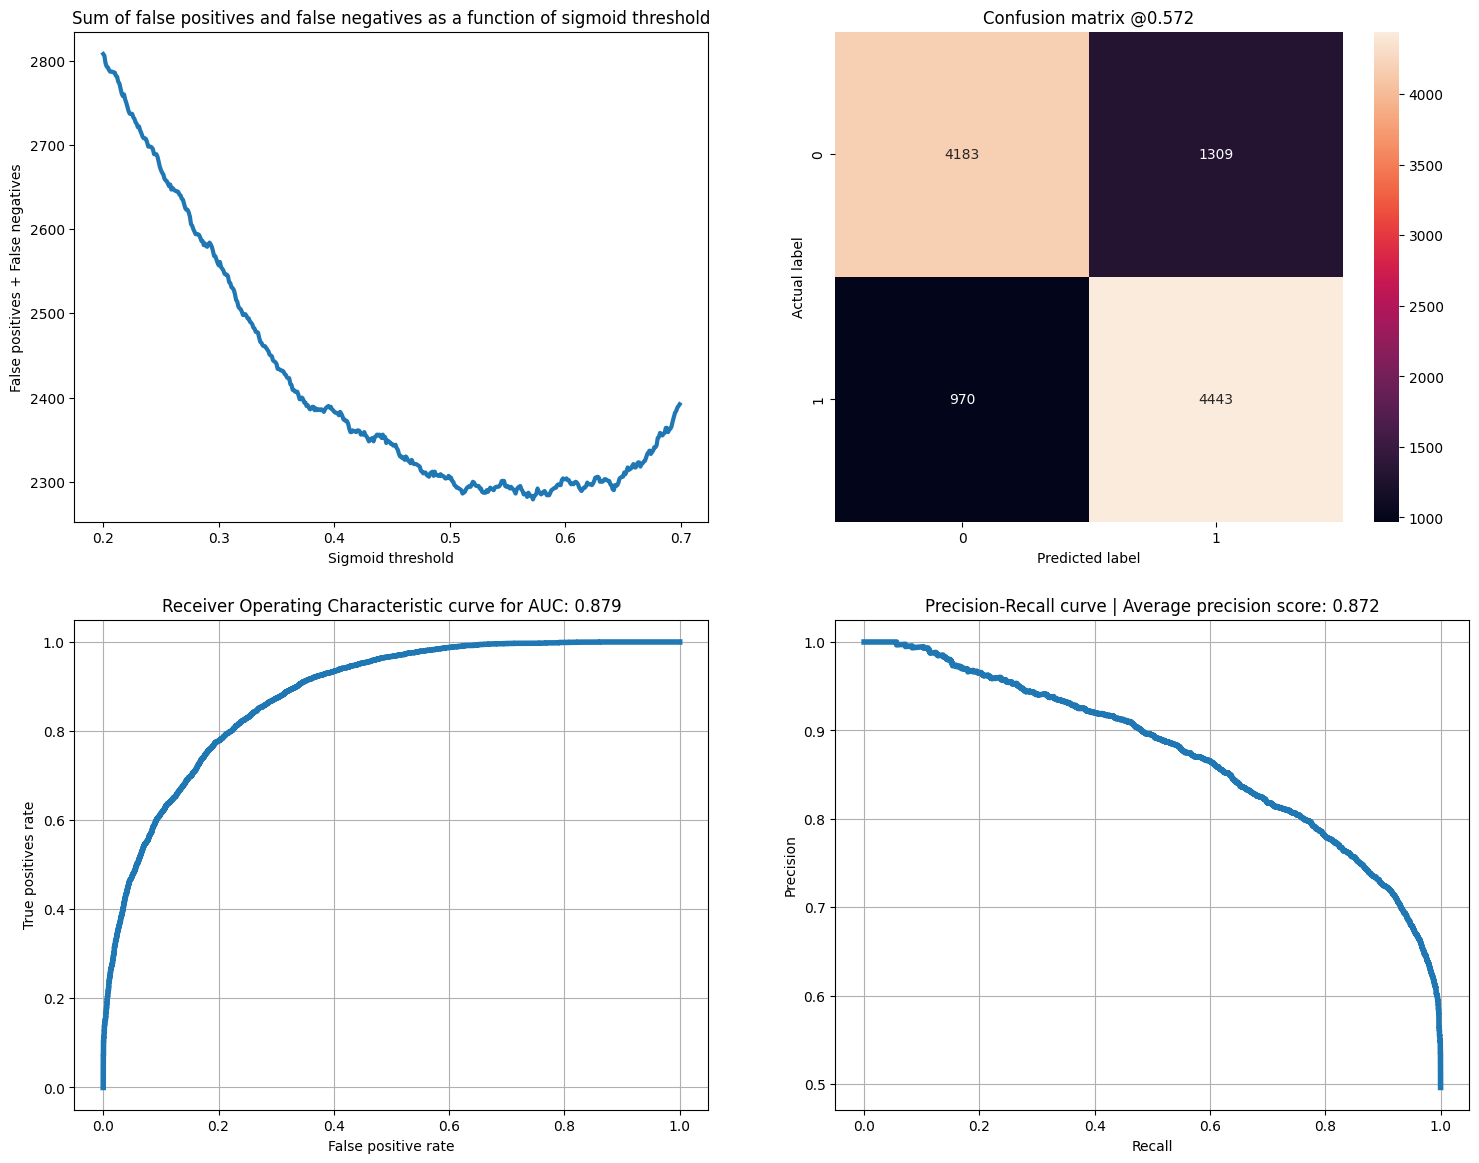

In [8]:
min_threshold = calculate_model_performance_metrics('model', test_generator, show_plots=True)

In [9]:
# # to check whether the given image is real or fake using the trained model

# from PIL import Image
# import tensorflow as tf
# import numpy as np

# # Replace these paths with your actual file locations
# MODEL_PATH = 'model_cnn.keras'  # Path to your saved model
# IMG_SIZE = 300  # Image size used during training (vgg_img_size)

# def load_image(image_path):
#   """Loads an image from the specified path and resizes it."""
#   img = Image.open(image_path).convert('RGB')  # Ensure RGB format
#   img = img.resize((IMG_SIZE, IMG_SIZE))
#   img_array = np.array(img) / 255.0  # Normalize pixel values (0-1)
#   img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
#   return img_array

# def predict_image(image_path):
#   """Loads the model, predicts the class, and returns the label."""
#   model = tf.keras.models.load_model(MODEL_PATH)
#   image = load_image(image_path)
#   prediction = model.predict(image)[0][0]  # Probability for 'real' class
#   label = 'Real Face' if prediction > 0.5 else 'Fake Face'
#   return label

# # User input for image path
# image_path = input("Enter the path to your image: ")

# # Make prediction and display result
# predicted_label = predict_image(image_path)
# print(f"The image is classified as: {predicted_label}")
